In [22]:
from libsvm.svmutil import *
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import dump_svmlight_file
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Spam Filter Using SVM

In [ ]:
df = pd.read_csv('datasets/spambase/spambase.data', header=None)

#Split into train and test data
df_train = df.sample(frac=0.8, axis=0)
df_test = df.drop(df_train.index)


Xtrain = df_train.iloc[:, :-1].values
ytrain = df_train.iloc[:, -1].values
Xtest = df_test.iloc[:, :-1].values
ytest = df_test.iloc[:, -1].values


# Write as LIBSVM format
dump_svmlight_file(Xtrain, ytrain, "spambase/spambase_train.libsvm", zero_based=False)
dump_svmlight_file(Xtest, ytest, "spambase/spambase_test.libsvm", zero_based=False)

#Read LIBSVM format
ytrain, Xtrain = svm_read_problem('spambase/spambase_train.libsvm')
ytest, Xtest = svm_read_problem('spambase/spambase_test.libsvm')



We optimize over the hyperparameter C which is the penalty enforced for tolerating misclassifications.

In [31]:
C = [0.01,0.1,1,2,4,10,25,50,100]

results =[]

for c in C:
    model = svm_train(ytrain, Xtrain, f'-t 0 -c {c} -q')
    _, p_acc,_ = svm_predict(ytest, Xtest, model)
    results.append({
        'C': c,
        'Accuracy': p_acc[0]
    })


df_results = pd.DataFrame(results)
print("\nResults Table:")
display(df_results)

Accuracy = 91.1957% (839/920) (classification)


Accuracy = 89.5652% (824/920) (classification)


Accuracy = 90.2174% (830/920) (classification)


Accuracy = 84.0217% (773/920) (classification)


Accuracy = 81.9565% (754/920) (classification)


Accuracy = 68.0435% (626/920) (classification)


Accuracy = 80.7609% (743/920) (classification)


Accuracy = 63.4783% (584/920) (classification)


Accuracy = 68.8043% (633/920) (classification)

Results Table:


,C,Accuracy
0,0.01,91.195652
1,0.10,89.565217
2,1.00,90.217391
3,2.00,84.021739
4,4.00,81.956522
5,10.00,68.043478
6,25.00,80.760870
7,50.00,63.478261
8,100.00,68.804348


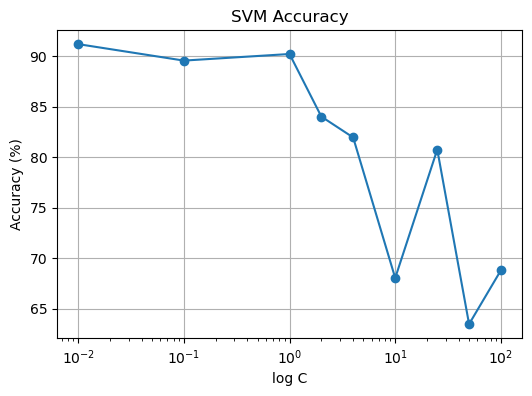

In [36]:

plt.figure(figsize=(6,4))
plt.plot(df_results['C'], df_results['Accuracy'], marker='o')
plt.xscale('log')
plt.xlabel('log C')
plt.ylabel('Accuracy (%)')
plt.title('SVM Accuracy')
plt.grid(True)
plt.show()

From the Table and Graph it is clear that the model performs optimally when the hyperparameter C is chosen really small. In other words, the model generalizes really well when it is able to tolerate misclassifying some samples. However, for really large values of C, the margin becomes very strict and variance in the data leads to aggressive fluctuations in accuracy. Nevertheless, large values for C generally implies overfitting and poor generalization.

# Spam filter using TFIDF-Vectorizer and SVM

In [26]:
df_sms = pd.read_csv('sms+spam+collection/SMSSpamCollection', header=None,sep="\t", names=['label', 'message'])

#Map labels as binary values
df_sms["label"] = df_sms["label"].map({"ham": 0, "spam": 1})



Xtrain, Xtest, ytrain, ytest = train_test_split(
    df_sms["message"],
    df_sms["label"],
    test_size=0.2,
    stratify=df_sms["label"]
)

#Gridsearch with 5 fold CV to find the best model and hyperparameters
param_grid = {
    'classifier__C': [0.01,0.1,1,2,4,10,25,50,100,200],
    'classifier__kernel': ['linear', 'rbf']
}

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english')),
    ('classifier', SVC())
])

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

grid_search.fit(Xtrain, ytrain)

y_pred = grid_search.predict(Xtest)

print(classification_report(ytest,y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.97      0.94      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



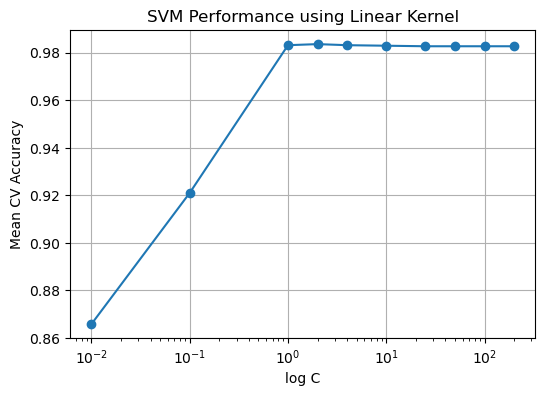

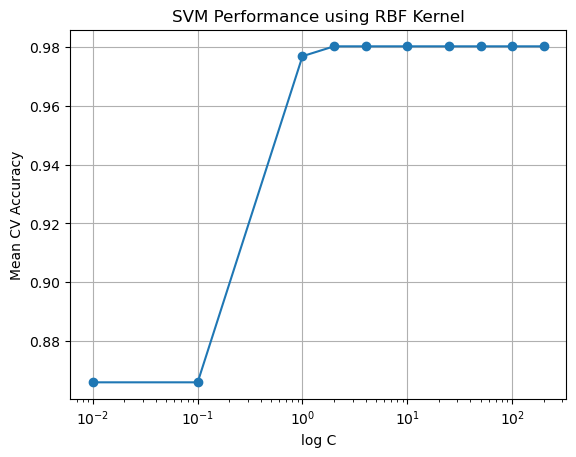

,param_classifier__kernel,param_classifier__C,mean_test_score
6,linear,2.00,0.983621
4,linear,1.00,0.983173
8,linear,4.00,0.983173
10,linear,10.00,0.982948
12,linear,25.00,0.982723
18,linear,200.00,0.982723
16,linear,100.00,0.982723
14,linear,50.00,0.982723
17,rbf,100.00,0.980254
15,rbf,50.00,0.980254


Highest Accuracy: 0.9836212146376571


In [27]:
results = pd.DataFrame(grid_search.cv_results_)


# Split results according to kernel type
results_linear = results[results["param_classifier__kernel"] == "linear"]
results_rbf = results[results["param_classifier__kernel"] == "rbf"]

# Plot linear
plt.figure(figsize=(6, 4))
plt.plot(results_linear["param_classifier__C"], results_linear["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("log C")

plt.ylabel("Mean CV Accuracy")
plt.title("SVM Performance using Linear Kernel")
plt.grid(True)
plt.show()

plt.plot(results_rbf["param_classifier__C"], results_rbf["mean_test_score"], marker="o")

plt.xscale("log")
plt.xlabel("log C")
plt.ylabel("Mean CV Accuracy")
plt.title("SVM Performance using RBF Kernel")
plt.grid(True)
plt.show()

display(
    results[
        ["param_classifier__kernel", "param_classifier__C","mean_test_score"]
    ].sort_values(by="mean_test_score", ascending=False)
)

print(f"Highest Accuracy: {grid_search.best_score_}")


The SVM Classifier with a linear kernel and a C-value of 2 performs the best for the SMS-Spam filtering data

# Using Logisitic Regression for Spam Filtering

We will perform hyperparameter tuning on a logistic regression model on the SMS-spam data. We optimize over the regularization strength and regularization penalty using Grid-Seach and CV.

In [28]:
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english')),
    ('classifier', LogisticRegression(solver='saga', max_iter=10000))
])


param_grid = {
    'classifier__C': [0.01,0.1,1,2,4,10,25,50,100,200],
    'classifier__penalty': ['l1', 'l2']
}


grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

grid_search.fit(Xtrain, ytrain)

y_pred = grid_search.predict(Xtest)

print(classification_report(ytest,y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [29]:
results = pd.DataFrame(grid_search.cv_results_)


display(
    results[
        ["param_classifier__penalty", "param_classifier__C","mean_test_score"]
    ].sort_values(by="mean_test_score", ascending=False)
)

print(f"Highest Accuracy: {grid_search.best_score_}")


,param_classifier__penalty,param_classifier__C,mean_test_score
19,l2,200.00,0.982499
17,l2,100.00,0.982050
15,l2,50.00,0.981825
13,l2,25.00,0.981376
11,l2,10.00,0.981152
18,l1,200.00,0.978910
14,l1,50.00,0.977339
9,l2,4.00,0.977114
16,l1,100.00,0.976890
12,l1,25.00,0.976665


Highest Accuracy: 0.9824986285374925


The logistic regression model performs comaparably similar to the SVM model with almost the same accuracy for both (~98%). The best hyperparameters after tuning for the SMS-Spam data is l2-regularization as penalty term and a high regularization strength of 200.